# Driver: Build IceCube maps from real data

This notebook runs `build_maps` from `src/data_to_maps.py` using the local SSD data release and writes outputs to `Results/`.

In [1]:
from pathlib import Path
import numpy as np

from icecube_population_project import build_maps as _build_maps


In [2]:
DATA_ROOT = Path("/mnt/my-ssd/Data_for_IceCube_Population_Project")

# Support either layout:
# 1) DATA_ROOT/icecube_10year_ps/events
# 2) DATA_ROOT/events
candidate = DATA_ROOT / "icecube_10year_ps"
release_root = candidate if (candidate / "events").exists() else DATA_ROOT

results_root = DATA_ROOT / "Results"
results_root.mkdir(parents=True, exist_ok=True)

output_npz = results_root / "icecube10y_counts_maps.npz"

print("release_root:", release_root)
print("output_npz:", output_npz)



release_root: /mnt/my-ssd/Data_for_IceCube_Population_Project
output_npz: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_counts_maps.npz


In [3]:
# Explicit settings: 10 TeV-10 PeV, 5 bins, nside=512, RING ordering
E_edges = np.logspace(4, 7, 6)
_build_maps(
    release_root=release_root,
    output_npz=output_npz,
    nside=512,
    nest=True,
    energy_edges_GeV=E_edges,
    per_season=False,
)

print("Saved maps to:", output_npz)
print("Saved summary to:", output_npz.with_suffix(".summary.json"))



[info] Processing season=IC40 file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC40_exp.csv
[info] Processing season=IC59 file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC59_exp.csv


[warn] missing season file, skipping: /mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC79_exp.csv


[info] Processing season=IC86_I file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_I_exp.csv
[info] Processing season=IC86_II file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_II_exp.csv
[info] Processing season=IC86_III file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_III_exp.csv
[info] Processing season=IC86_IV file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_IV_exp.csv
[info] Processing season=IC86_V file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_V_exp.csv
[info] Processing season=IC86_VI file=/mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_VI_exp.csv


[warn] missing season file, skipping: /mnt/my-ssd/Data_for_IceCube_Population_Project/events/IC86_VII_exp.csv


[done] Wrote maps: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_counts_maps.npz
[done] Wrote summary: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_counts_maps.summary.json
Saved maps to: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_counts_maps.npz
Saved summary to: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_counts_maps.summary.json


In [4]:
arr = np.load(output_npz)
print("counts_map shape:", arr["counts_map"].shape)
print("counts_map dtype:", arr["counts_map"].dtype)
print("nside:", int(arr["nside"]))
print("energy edges (GeV):", arr["E_edges_GeV"])



counts_map shape: (5, 3145728)
counts_map dtype: int64
nside: 512
energy edges (GeV): [   10000.            39810.71705535   158489.31924611   630957.34448019
  2511886.43150958 10000000.        ]


## Plot maps (Aitoff + declination histogram)

Equatorial J2000 sky maps in Aitoff projection with RA increasing to the left, plus per-bin declination histograms.

/tmp/ipykernel_866750/2959424846.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


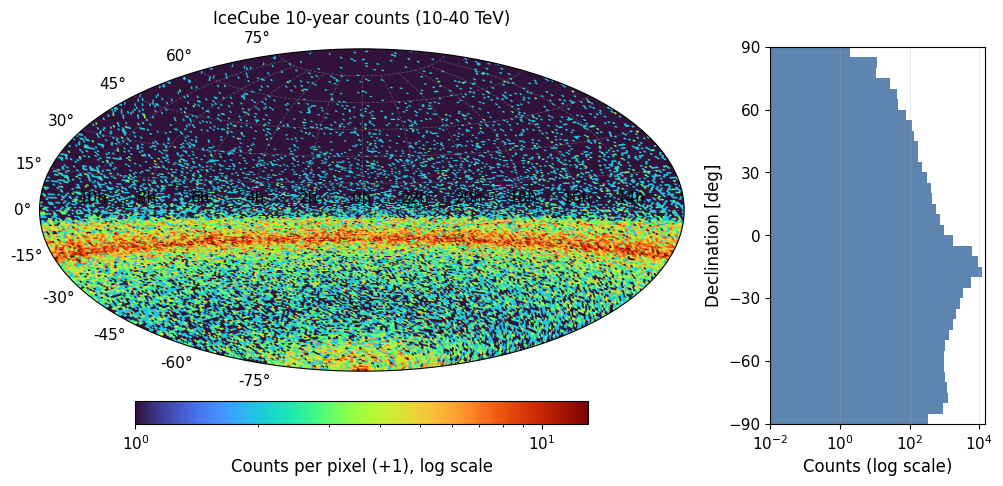

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_aitoff_dec_hist_bin00.png


/tmp/ipykernel_866750/2959424846.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


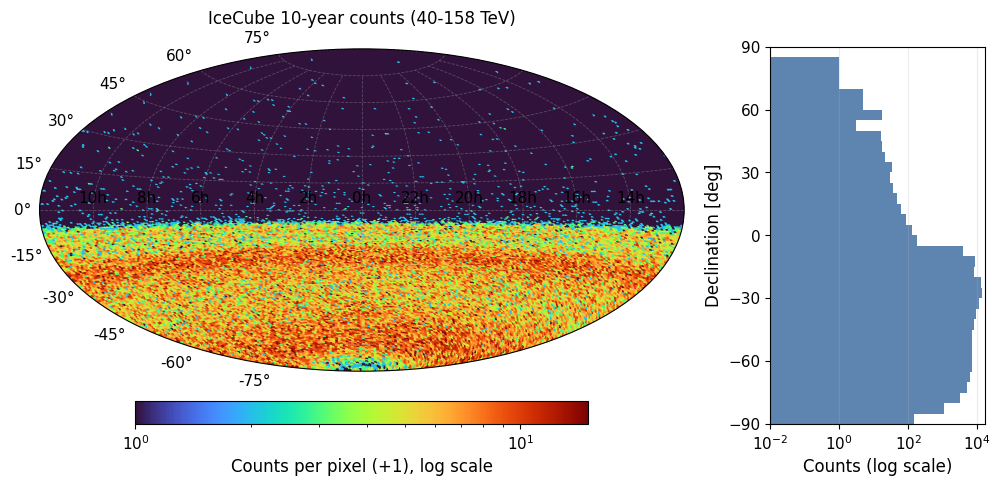

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_aitoff_dec_hist_bin01.png


/tmp/ipykernel_866750/2959424846.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


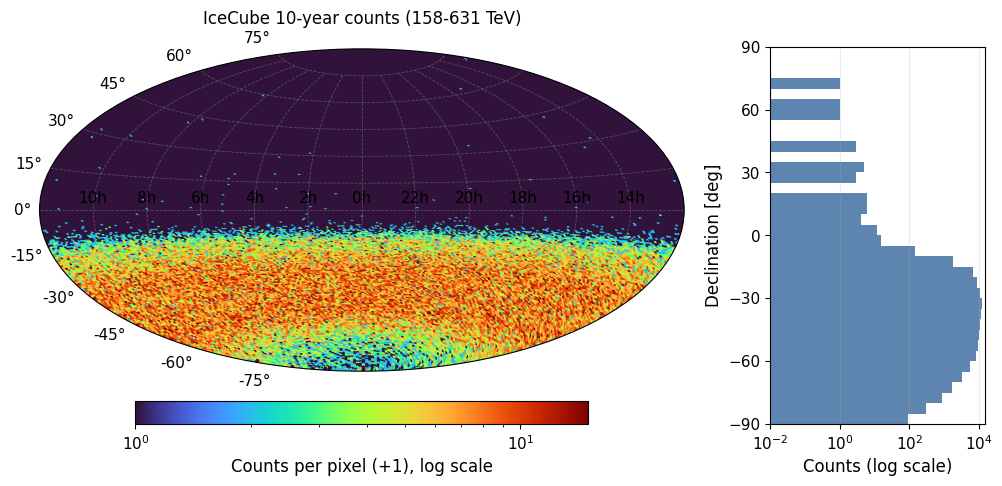

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_aitoff_dec_hist_bin02.png


/tmp/ipykernel_866750/2959424846.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


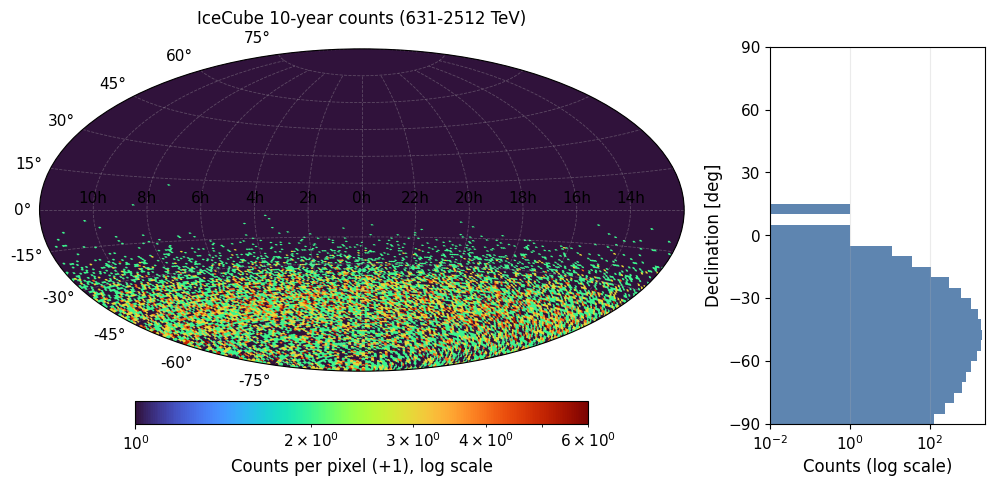

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_aitoff_dec_hist_bin03.png


/tmp/ipykernel_866750/2959424846.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


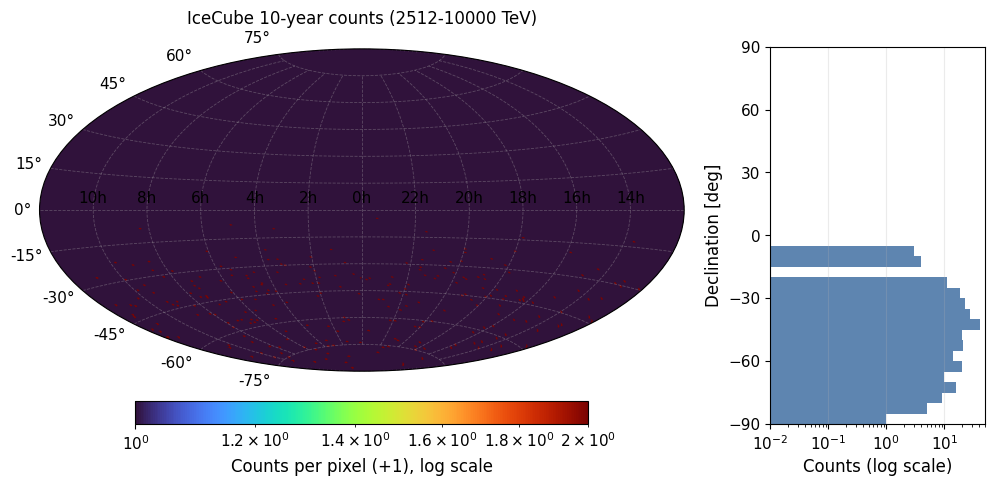

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Results/icecube10y_aitoff_dec_hist_bin04.png
nside: 512 nest: True
Displayed and saved 5 energy-bin figures.


In [5]:
import healpy as hp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import gridspec

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

with np.load(output_npz) as data:
    counts_map = data["counts_map"].astype(float)
    E_edges_GeV = data["E_edges_GeV"].astype(float)
    nside_loaded = int(np.atleast_1d(data["nside"])[0])
    nest_loaded = bool(np.atleast_1d(data["nest"])[0]) if "nest" in data.files else True

order_in = "NEST" if nest_loaded else "RING"
nside_plot = min(64, nside_loaded)

# Declination bins for the side histogram (computed on the full-resolution map)
npix_full = hp.nside2npix(nside_loaded)
theta_full, _ = hp.pix2ang(nside_loaded, np.arange(npix_full), nest=nest_loaded)
dec_full_deg = 90.0 - np.degrees(theta_full)
dec_bins = np.linspace(-90, 90, 37)
dec_centers = 0.5 * (dec_bins[:-1] + dec_bins[1:])
dec_heights = np.diff(dec_bins)

# Fixed RA ticks in hours for astronomical convention (RA increasing to the left)
xticks = np.radians(np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]))
xticklabels = ["10h", "8h", "6h", "4h", "2h", "0h", "22h", "20h", "18h", "16h", "14h"]

n_bins = counts_map.shape[0]

for i in range(n_bins):
    m_full = counts_map[i]
    counts_vs_dec, _ = np.histogram(dec_full_deg, bins=dec_bins, weights=m_full)

    # Downsample only for plotting speed/clarity while conserving total counts.
    m_plot = hp.ud_grade(
        m_full,
        nside_out=nside_plot,
        order_in=order_in,
        order_out="RING",
        power=-2,
    )

    npix_plot = hp.nside2npix(nside_plot)
    theta_plot, phi_plot = hp.pix2ang(nside_plot, np.arange(npix_plot), nest=False)
    dec_plot = 0.5 * np.pi - theta_plot

    # Aitoff uses longitude in [-pi, pi]; sign flip gives RA increasing to the left.
    ra_wrap = (phi_plot + np.pi) % (2 * np.pi) - np.pi
    lon_plot = -ra_wrap

    m_color = np.maximum(m_plot, 0.0) + 1.0
    positive = m_color[m_plot > 0]
    vmax = np.percentile(positive, 99.7) if positive.size > 0 else 2.0
    vmax = max(float(vmax), 2.0)

    e0_tev = E_edges_GeV[i] / 1e3
    e1_tev = E_edges_GeV[i + 1] / 1e3
    title = f"IceCube 10-year counts ({e0_tev:.0f}-{e1_tev:.0f} TeV)"

    fig = plt.figure(figsize=(12.2, 4.9))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.6, 1.2], wspace=0.2)

    ax_map = fig.add_subplot(gs[0], projection="aitoff")
    sc = ax_map.scatter(
        lon_plot,
        dec_plot,
        c=m_color,
        s=8,
        cmap="turbo",
        norm=LogNorm(vmin=1.0, vmax=vmax),
        linewidths=0,
        rasterized=True,
    )
    ax_map.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax_map.set_xticks(xticks)
    ax_map.set_xticklabels(xticklabels)
    ax_map.set_title(title, pad=18)

    cbar = fig.colorbar(sc, ax=ax_map, orientation="horizontal", pad=0.08, fraction=0.06)
    cbar.set_label("Counts per pixel (+1), log scale")

    ax_hist = fig.add_subplot(gs[1])
    hist_floor = 1e-2
    counts_plot = np.clip(counts_vs_dec.astype(float), hist_floor, None)
    ax_hist.barh(dec_centers, counts_plot, height=dec_heights, color="#4C78A8", alpha=0.9)
    ax_hist.set_ylim(-90, 90)
    ax_hist.set_yticks(np.arange(-90, 91, 30))
    ax_hist.set_xscale("log")
    ax_hist.set_xlim(hist_floor, max(float(np.max(counts_vs_dec)), 1.0) * 1.2)
    ax_hist.set_xlabel("Counts (log scale)")
    ax_hist.set_ylabel("Declination [deg]")
    ax_hist.grid(True, axis="x", alpha=0.25)

    #fig.suptitle("J2000 equatorial coordinates (Aitoff), RA increasing to the left", y=0.99, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    figure_path = results_root / f"icecube10y_aitoff_dec_hist_bin{i:02d}.png"
    fig.savefig(figure_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", figure_path)

print("nside:", nside_loaded, "nest:", nest_loaded)
print("Displayed and saved", n_bins, "energy-bin figures.")
